# PolarGAP aeromagnetic levelling

In [1]:
%load_ext autoreload
%autoreload 2


import logging

import cmocean
import matplotlib.pyplot as plt
import pandas as pd
import verde as vd

import airbornegeo

# setup logging to get some additional info from the airbornegeo functions
logging.getLogger("airbornegeo").setLevel("INFO")
logging.basicConfig()

## Load data

In [2]:
data_df = pd.read_csv("data/PolarGAP_magnetic_survey_blocked.csv")

data_df = data_df.drop(columns="line")

data_df = data_df.rename(
    columns={
        "MagB30RTC": "unlevelled_tfa",
        "MagL_B30RTC": "published_levelled_tfa",
    }
)

data_df = data_df[
    [
        "easting",
        "northing",
        "Elev",
        "distance_along_flight",
        "unixtime",
        "flight",
        "published_levelling_correction",
        "unlevelled_tfa",
        "published_levelled_tfa",
    ]
]

data_df = data_df.sort_values(["flight", "unixtime"])
data_df = data_df.dropna(subset=["unlevelled_tfa", "Elev"], how="any")

data_df.head()

,easting,northing,Elev,distance_along_flight,unixtime,flight,published_levelling_correction,unlevelled_tfa,published_levelled_tfa
6,-726977.495045,741483.042592,423.460,3247.624650,1.450202e+09,1,0.0,-83.880,-83.880
7,-726470.616701,741599.990804,463.925,3767.844206,1.450202e+09,1,0.0,-82.915,-82.915
8,-725988.389576,741687.954909,498.990,4258.101493,1.450202e+09,1,0.0,-84.850,-84.850
9,-725519.822728,741766.773750,524.450,4733.254367,1.450202e+09,1,0.0,-85.960,-85.960
10,-725011.350434,741849.901747,552.655,5248.482927,1.450202e+09,1,0.0,-86.505,-86.505


In [3]:
data_df.describe()

,easting,northing,Elev,distance_along_flight,unixtime,flight,published_levelling_correction,unlevelled_tfa,published_levelled_tfa
count,64895.000000,64895.000000,64895.000000,6.489500e+04,6.489500e+04,64895.000000,64895.000000,64895.000000,64895.000000
mean,-105541.066793,205563.587994,2919.828885,5.007962e+05,1.451686e+09,18.412867,-0.606166,-7.212939,-7.819175
std,292675.389379,309282.559911,456.844799,2.844486e+05,8.926196e+05,10.204416,23.026873,80.326959,78.139104
min,-726977.495045,-486226.506678,423.460000,2.380619e+02,1.450202e+09,1.000000,-165.330000,-358.670000,-358.670000
25%,-371123.439905,-24624.796781,2806.292500,2.587746e+05,1.451050e+09,10.000000,-10.820000,-60.450000,-59.590000
50%,-63879.450095,152635.147254,2927.190000,4.882867e+05,1.451600e+09,18.000000,0.000000,-22.250000,-22.860000
75%,142273.736001,443415.225314,3211.560000,7.356324e+05,1.452472e+09,27.000000,9.100000,32.980000,28.435000
max,481430.890988,876164.436520,4326.505000,1.094965e+06,1.453326e+09,36.000000,154.105000,535.490000,545.605000


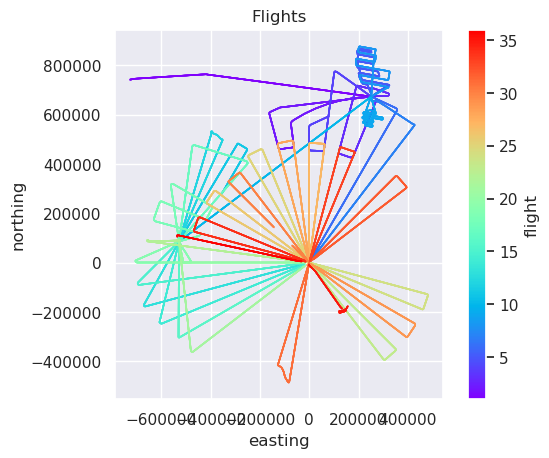

In [4]:
data_df.plot.scatter(
    "easting",
    "northing",
    c="flight",
    s=0.02,
    cmap="rainbow",
    title="Flights",
).set_aspect("equal")

# Cross-over levelling

## Find intersections

In [5]:
# calculate theoretical intersection points
inters = airbornegeo.create_intersection_table(
    data_df,
    line_column="flight",
    method="network",
    buffer_dist=2e3,
    cutoff_dist=5e3,
)
inters

Line pairs:   0%|          | 0/630 [00:00<?, ?it/s]

INFO:airbornegeo:found 146 intersections


INFO:airbornegeo:removed 0 intersection point(s) with a max distance greater than 5 km


,line1,line2,is_buffered,geometry,easting,northing,max_dist
0,1,3,False,POINT (182741 682032),182741.0,682032.0,237.534666
1,1,4,True,POINT (91427 694557),91427.0,694557.0,153.598234
2,2,3,False,POINT (177961 664168),177961.0,664168.0,41.220514
3,2,3,False,POINT (178543 666380),178543.0,666380.0,160.220192
4,2,4,False,POINT (85987 653161),85987.0,653161.0,184.863097
...,...,...,...,...,...,...,...
141,24,31,False,POINT (-16 -75),-16.0,-75.0,89.211473
142,27,31,False,POINT (-1583 -9433),-1583.0,-9433.0,148.928759
143,27,31,False,POINT (-123 -719),-123.0,-719.0,185.531499
144,27,35,False,POINT (-1618 -9513),-1618.0,-9513.0,236.249147


In [6]:
# see which lines don't have intersections
airbornegeo.lines_without_intersections(data_df, inters, line_column="flight")

[np.int64(29), np.int64(32)]

Text(0.5, 1.0, 'Histogram of max distance between intersection and data')

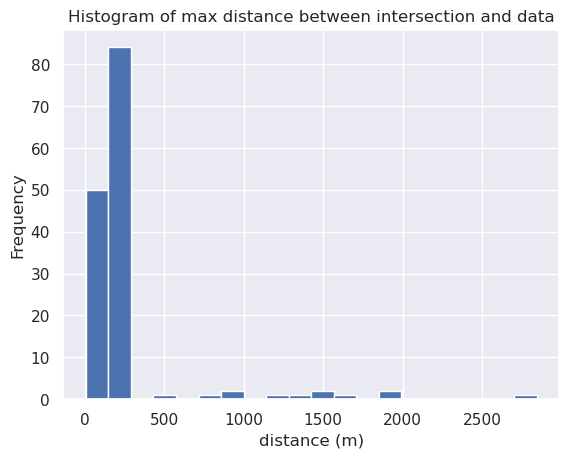

In [7]:
ax = inters.max_dist.plot.hist(bins=20)
ax.set_xlabel("distance (m)")
ax.set_title("Histogram of max distance between intersection and data")

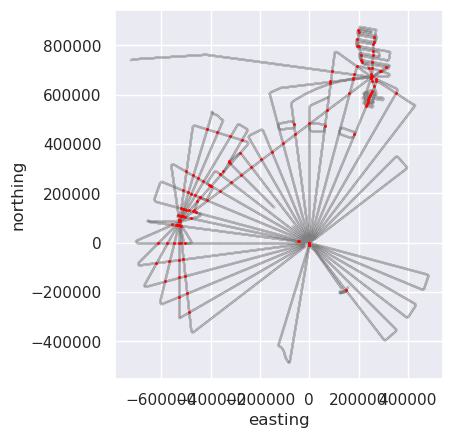

In [8]:
ax = data_df.plot.scatter(
    "easting",
    "northing",
    color="gray",
    s=0.001,
)
inters.plot.scatter(
    "easting",
    "northing",
    color="red",
    s=1,
    ax=ax,
)
ax.set_aspect("equal")

## Add intersections as rows to the dataframe

In [9]:
data_df, inters = airbornegeo.interpolate_intersections(
    data_df,
    inters,
    line_column="flight",
    to_interp="unlevelled_tfa",
    interp_on="distance_along_flight",
    method="linear",
    extrapolate=True,
)
inters

Interpolating segments:   0%|          | 0/36 [00:00<?, ?it/s]

,line1,line2,is_buffered,geometry,easting,northing,max_dist,dist_along_line1,dist_along_line2,line1_interpolation_type,line2_interpolation_type
0,1,3,False,POINT (182741 682032),182741.0,682032.0,237.534666,9.195994e+05,582724.575596,interpolated,interpolated
1,1,4,True,POINT (91427 694557),91427.0,694557.0,153.598234,8.274170e+05,699796.259216,interpolated,interpolated
2,2,3,False,POINT (177961 664168),177961.0,664168.0,41.220514,1.011124e+06,564228.024085,interpolated,interpolated
3,2,3,False,POINT (178543 666380),178543.0,666380.0,160.220192,7.879179e+04,566515.396214,interpolated,interpolated
4,2,4,False,POINT (85987 653161),85987.0,653161.0,184.863097,9.184676e+05,658034.921315,interpolated,interpolated
...,...,...,...,...,...,...,...,...,...,...,...
141,24,31,False,POINT (-16 -75),-16.0,-75.0,89.211473,1.072252e+06,17279.660322,interpolated,interpolated
142,27,31,False,POINT (-1583 -9433),-1583.0,-9433.0,148.928759,1.075883e+06,26773.141621,interpolated,interpolated
143,27,31,False,POINT (-123 -719),-123.0,-719.0,185.531499,1.067039e+06,17933.094885,interpolated,interpolated
144,27,35,False,POINT (-1618 -9513),-1618.0,-9513.0,236.249147,1.075970e+06,7719.431183,interpolated,interpolated


In [10]:
# see which lines don't have intersections
airbornegeo.lines_without_intersections(data_df, inters, line_column="flight")

[np.int64(29), np.int64(32)]

## Calculate initial cross-over errors

In [11]:
inters = airbornegeo.calculate_crossover_errors(
    data_df,
    inters,
    data_col="unlevelled_tfa",
    line_column="flight",
)
inters.head()

,line1,line2,is_buffered,geometry,easting,northing,max_dist,dist_along_line1,dist_along_line2,line1_interpolation_type,line2_interpolation_type,crossover_error_0
0,1,3,False,POINT (182741 682032),182741.0,682032.0,237.534666,9.195994e+05,582724.575596,interpolated,interpolated,-44.967037
1,1,4,True,POINT (91427 694557),91427.0,694557.0,153.598234,8.274170e+05,699796.259216,interpolated,interpolated,-39.582973
2,2,3,False,POINT (177961 664168),177961.0,664168.0,41.220514,1.011124e+06,564228.024085,interpolated,interpolated,-2.797433
3,2,3,False,POINT (178543 666380),178543.0,666380.0,160.220192,7.879179e+04,566515.396214,interpolated,interpolated,-11.564578
4,2,4,False,POINT (85987 653161),85987.0,653161.0,184.863097,9.184676e+05,658034.921315,interpolated,interpolated,0.876803


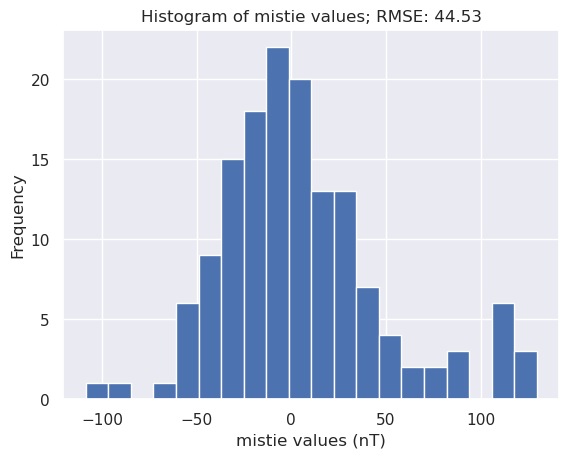

In [12]:
ax = inters.crossover_error_0.plot.hist(bins=20)
ax.set_xlabel("mistie values (nT)")
ax.set_title(
    f"Histogram of mistie values; RMSE: {round(airbornegeo.rmse(inters.crossover_error_0), 2)}"
);

In [13]:
airbornegeo.plotly_points(
    inters,
    color_col=inters.columns[-1],
    hover_cols=["line1", "line2"],
    robust=True,
    absolute=True,
    cmap="balance",
    size=5,
    edge_width=1,
)

## Level with a trend

  0%|          | 0/20 [00:00<?, ?it/s]

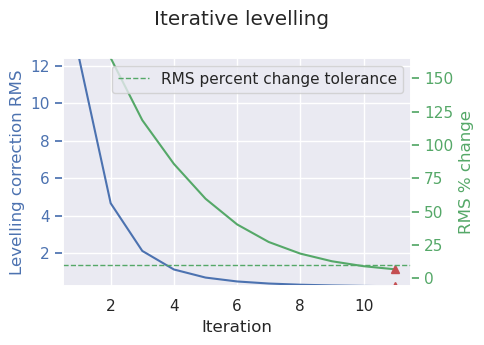

INFO:airbornegeo:
Levelling terminated after 11 iterations because there was no significant variation in the RMS (delta RMS of 6.84%) of the levelling corrections over 2 iterations 
Change parameter 'rms_percent_change_tolerance' (10%) if desired.


In [14]:
data_df, inters_trend = airbornegeo.crossover_network_levelling(
    data_df,
    inters,
    data_col="unlevelled_tfa",
    levelled_col="levelled_trend",
    line_column="flight",
    distance_column="distance_along_flight",
    degree=0,
    max_iterations=20,
    plot_dynamic_convergence=True,
)

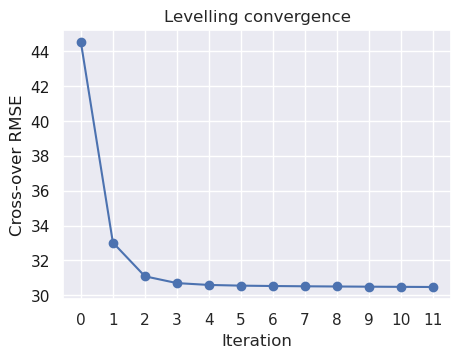

In [15]:
airbornegeo.plot_levelling_convergence(inters_trend)

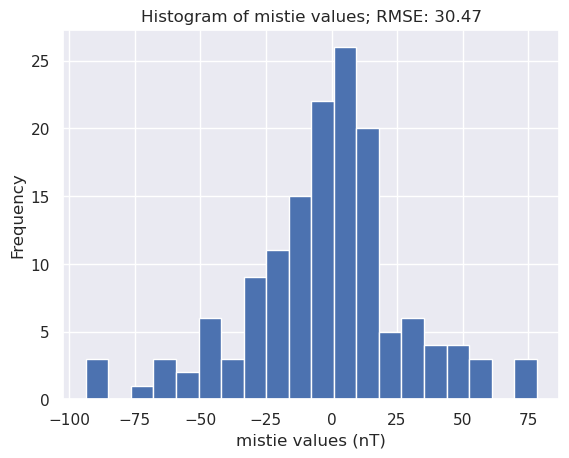

In [16]:
ax = inters_trend[inters_trend.columns[-1]].plot.hist(bins=20)
ax.set_xlabel("mistie values (nT)")
ax.set_title(
    f"Histogram of mistie values; RMSE: {round(airbornegeo.rmse(inters_trend[inters_trend.columns[-1]]), 2)}"
);

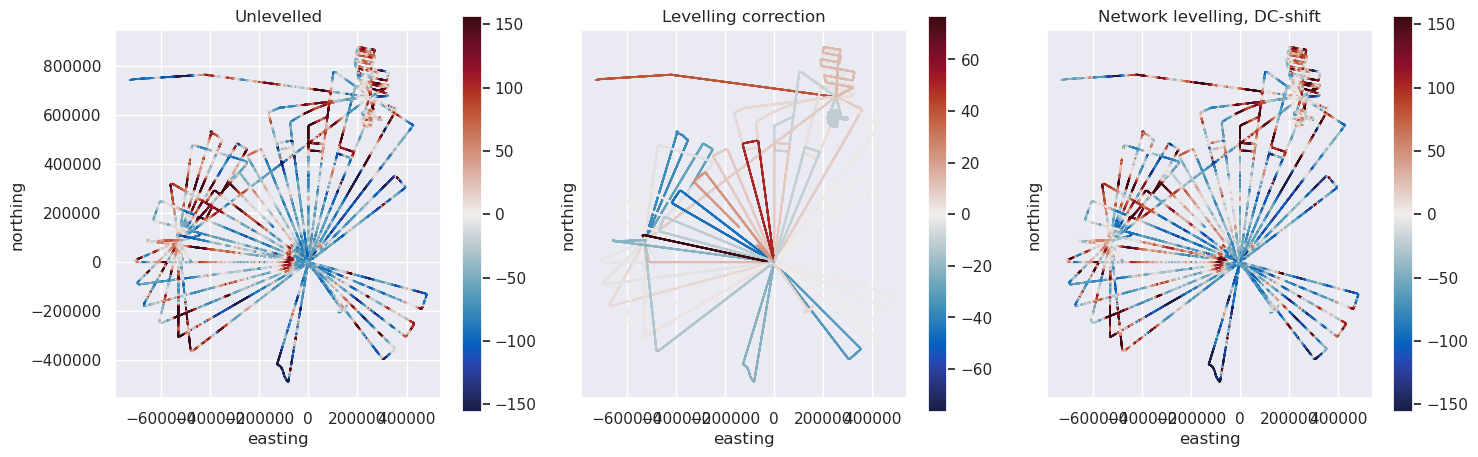

In [17]:
fig, axs = plt.subplots(1, 3, figsize=(15, 40))

data_df["levelling_correction"] = data_df.levelled_trend - data_df.unlevelled_tfa
df = data_df

max_abs = vd.maxabs(df.unlevelled_tfa, percentile=95)
ax = df.plot.scatter(
    "easting",
    "northing",
    c="unlevelled_tfa",
    s=0.1,
    ax=axs[0],
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
    colorbar=False,
    title="Unlevelled",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

max_abs_level_corr = vd.maxabs(df.levelling_correction, percentile=99.5)
ax = df.plot.scatter(
    "easting",
    "northing",
    c="levelling_correction",
    s=0.1,
    ax=axs[1],
    cmap=cmocean.cm.balance,
    vmin=-max_abs_level_corr,
    vmax=max_abs_level_corr,
    colorbar=False,
    title="Levelling correction",
)
ax.set_yticks([])
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

ax = df.plot.scatter(
    "easting",
    "northing",
    c="levelled_trend",
    s=0.1,
    ax=axs[2],
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
    colorbar=False,
    title="Network levelling, DC-shift",
)
ax.set_yticks([])
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

plt.tight_layout()
plt.show()

## Level with a filter

  0%|          | 0/20 [00:00<?, ?it/s]

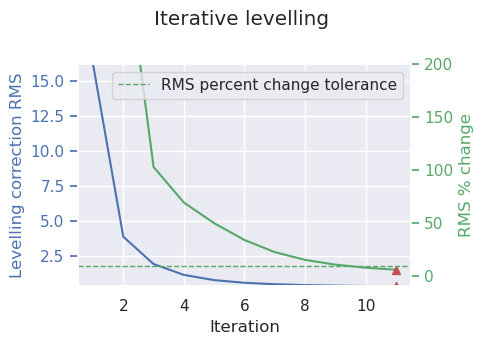

INFO:airbornegeo:
Levelling terminated after 11 iterations because there was no significant variation in the RMS (delta RMS of 6.18%) of the levelling corrections over 2 iterations 
Change parameter 'rms_percent_change_tolerance' (10%) if desired.


In [18]:
data_df, inters_filter = airbornegeo.crossover_network_levelling(
    data_df,
    inters,
    data_col="unlevelled_tfa",
    levelled_col="levelled_filter",
    line_column="flight",
    distance_column="distance_along_flight",
    filter_type="g200000",
    max_iterations=20,
    plot_dynamic_convergence=True,
)

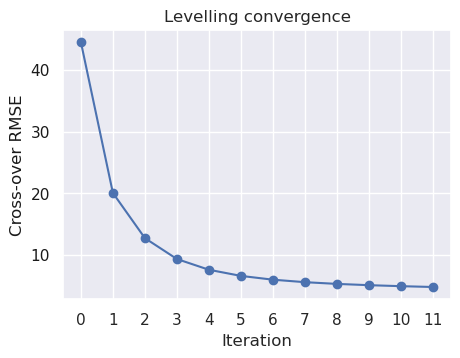

In [19]:
airbornegeo.plot_levelling_convergence(inters_filter)

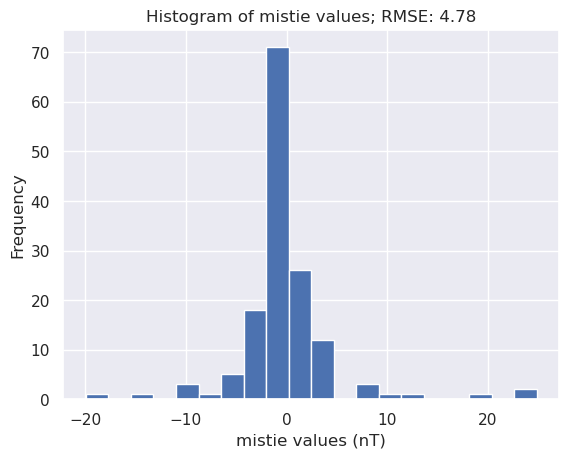

In [20]:
ax = inters_filter[inters_filter.columns[-1]].plot.hist(bins=20)
ax.set_xlabel("mistie values (nT)")
ax.set_title(
    f"Histogram of mistie values; RMSE: {round(airbornegeo.rmse(inters_filter[inters_filter.columns[-1]]), 2)}"
);

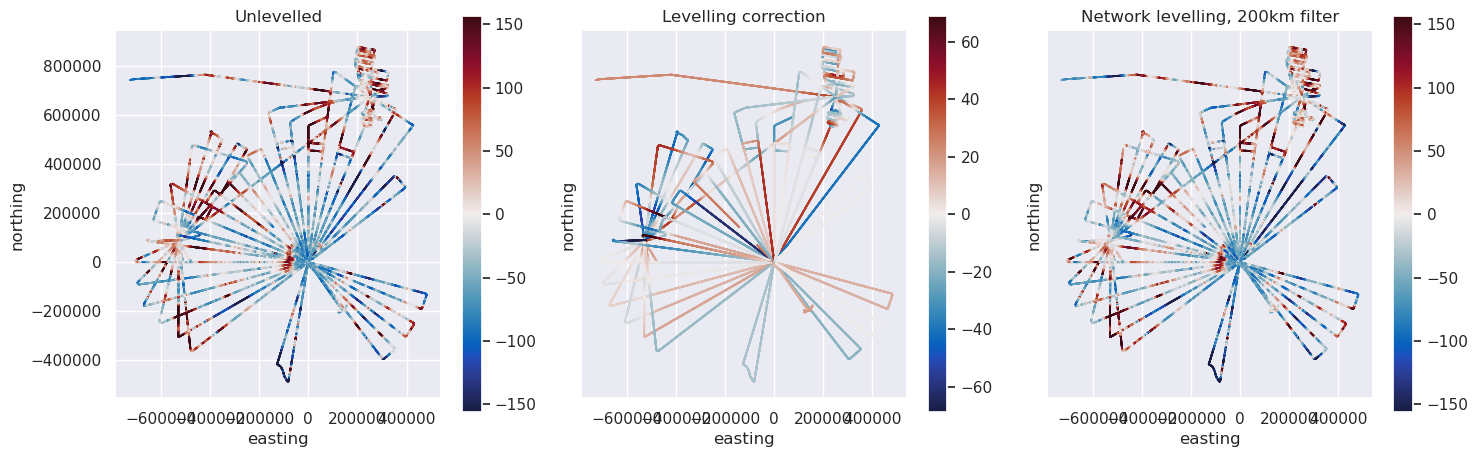

In [21]:
fig, axs = plt.subplots(1, 3, figsize=(15, 40))

data_df["levelling_correction"] = data_df.levelled_filter - data_df.unlevelled_tfa
df = data_df

max_abs = vd.maxabs(df.unlevelled_tfa, percentile=95)
ax = df.plot.scatter(
    "easting",
    "northing",
    c="unlevelled_tfa",
    s=0.1,
    ax=axs[0],
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
    colorbar=False,
    title="Unlevelled",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

max_abs_level_corr = vd.maxabs(df.levelling_correction, percentile=99.5)
ax = df.plot.scatter(
    "easting",
    "northing",
    c="levelling_correction",
    s=0.1,
    ax=axs[1],
    cmap=cmocean.cm.balance,
    vmin=-max_abs_level_corr,
    vmax=max_abs_level_corr,
    colorbar=False,
    title="Levelling correction",
)
ax.set_yticks([])
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

ax = df.plot.scatter(
    "easting",
    "northing",
    c="levelled_filter",
    s=0.1,
    ax=axs[2],
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
    colorbar=False,
    title="Network levelling, 200km filter",
)
ax.set_yticks([])
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

plt.tight_layout()
plt.show()

<Axes: ylabel='Frequency'>

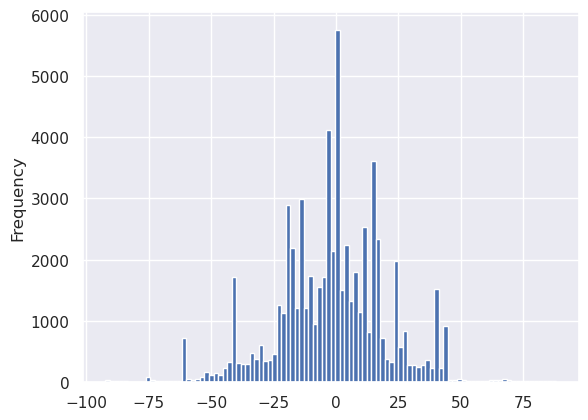

In [22]:
data_df.levelling_correction.plot.hist(bins=100)